In [2]:
import pandas as pd

df = pd.read_csv("hf://datasets/dazzle-nu/CIS435-CreditCardFraudDetection/fraudTrain.csv")
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,Unnamed: 23,6006
0,0,1/1/19 0:00,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,3495,"Psychologist, counselling",3/9/88,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,NaN,NaN
1,1,1/1/19 0:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,149,Special educational needs teacher,6/21/78,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN,NaN
2,2,1/1/19 0:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,4154,Nature conservation officer,1/19/62,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,NaN,NaN
3,3,1/1/19 0:01,3.534090e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,1939,Patent attorney,1/12/67,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN,NaN
4,4,1/1/19 0:03,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,99,Dance movement psychotherapist,3/28/86,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,NaN,NaN


In [12]:
# Split the transaction timestamp into date and time columns.
if 'trans_date_trans_time' in df.columns:
    transaction_timestamp = pd.to_datetime(
        df['trans_date_trans_time'],
        format='%Y-%m-%d %H:%M:%S'
    )
    df['trans_date'] = transaction_timestamp.dt.date
    df['trans_time'] = transaction_timestamp.dt.time
    df = df.drop(columns=['trans_date_trans_time'])

df[['trans_date', 'trans_time']].head()

,trans_date,trans_time
0,2019-01-01,00:00:00
1,2019-01-01,00:00:00
2,2019-01-01,00:00:00
3,2019-01-01,00:01:00
4,2019-01-01,00:03:00


<Axes: >

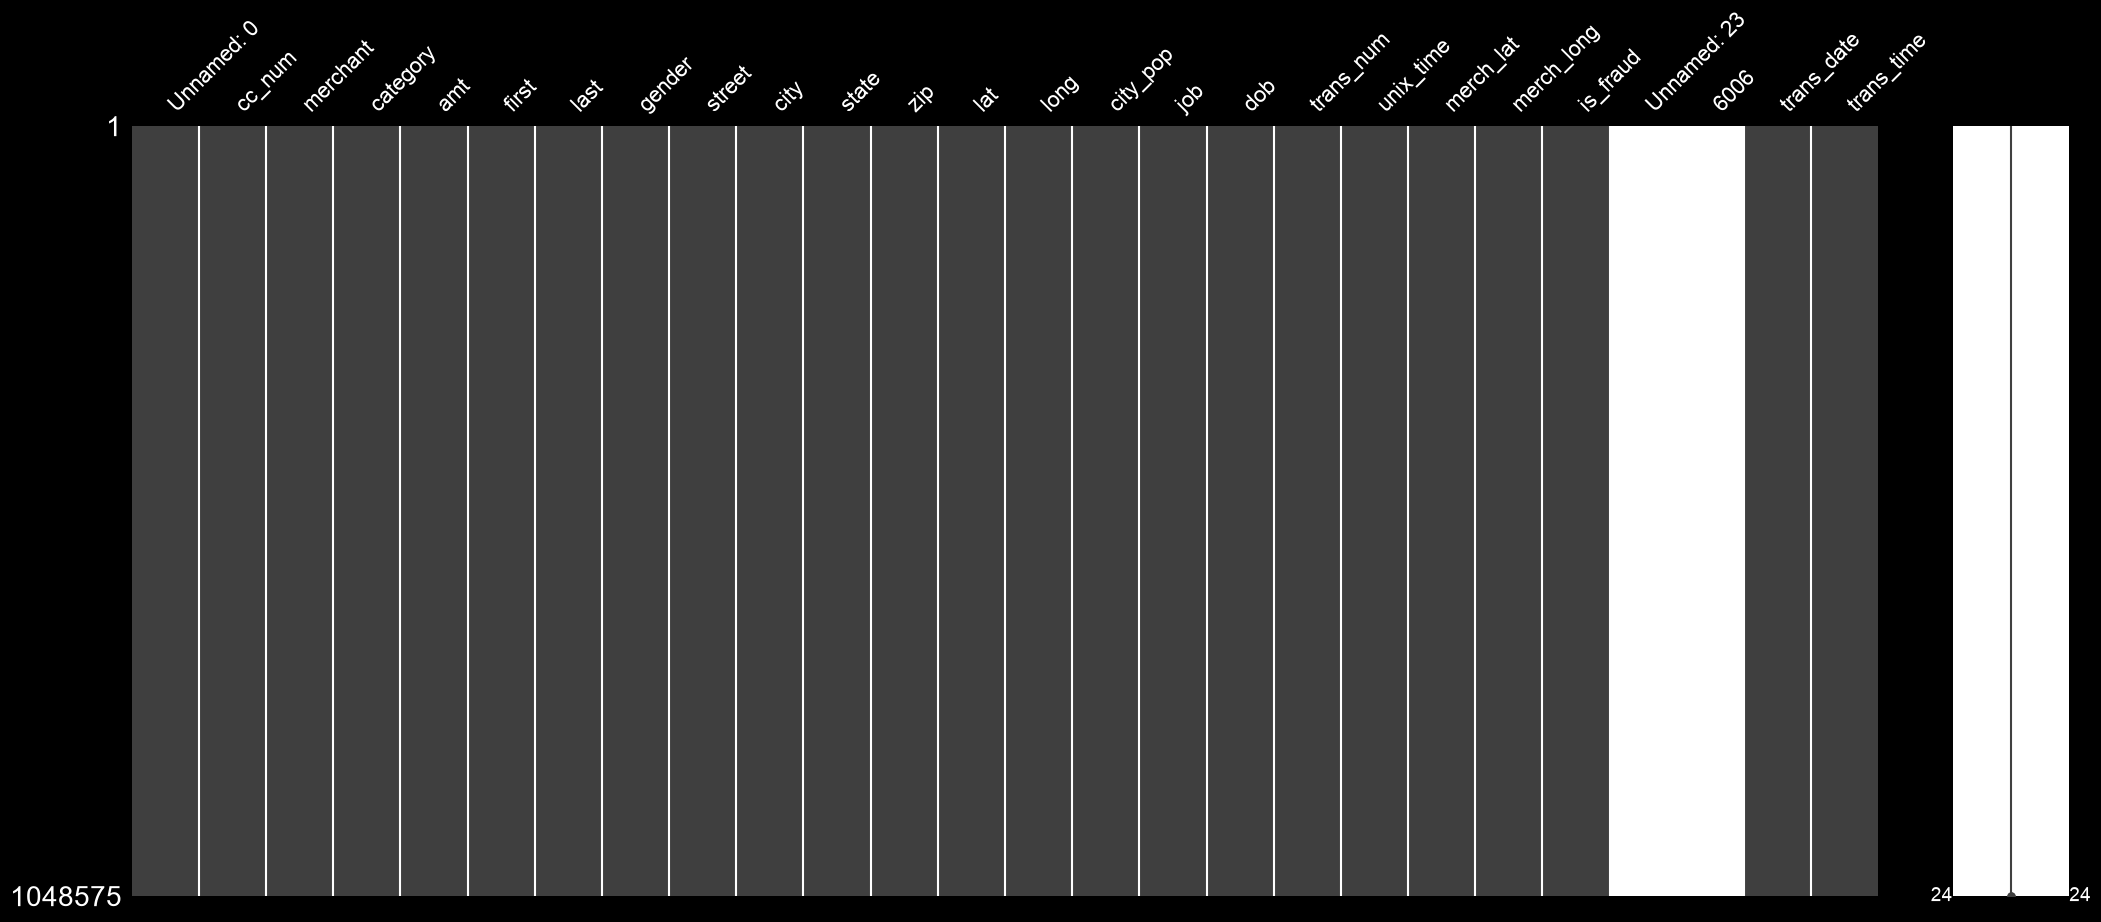

In [4]:
import missingno

missingno.matrix(df)

In [5]:
duplicate_rows = df[df.duplicated()]
print(len(duplicate_rows))

0


In [6]:
df_isFraud = df[df['is_fraud'] == 1]
print(len(df_isFraud))
df_notFraud = df[df['is_fraud'] == 0]
print(len(df_notFraud))
print("Percentage of fraudulent transactions: {:.2f}%".format(len(df_isFraud) / len(df) * 100))

6006
1042569
Percentage of fraudulent transactions: 0.57%


In [7]:
df.columns

Index(['Unnamed: 0', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last',
       'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop',
       'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long',
       'is_fraud', 'Unnamed: 23', '6006', 'trans_date', 'trans_time'],
      dtype='str')

In [8]:
df_isFraud.head()

,Unnamed: 0,cc_num,merchant,category,amt,first,last,gender,street,city,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,Unnamed: 23,6006,trans_date,trans_time
2449,2449,4.613310e+12,fraud_Rutherford-Mertz,grocery_pos,281.06,Jason,Murphy,M,542 Steve Curve Suite 011,Collettsville,...,9/15/88,e8a81877ae9a0a7f883e15cb39dc4022,1325466397,36.430124,-81.179483,1,NaN,NaN,2019-01-02,01:06:00
2472,2472,3.401870e+14,"fraud_Jenkins, Hauck and Friesen",gas_transport,11.52,Misty,Hart,F,27954 Hall Mill Suite 575,San Antonio,...,10/28/60,bc7d41c41103877b03232f03f1f8d3f5,1325468849,29.819364,-99.142791,1,NaN,NaN,2019-01-02,01:47:00
2523,2523,3.401870e+14,fraud_Goodwin-Nitzsche,grocery_pos,276.31,Misty,Hart,F,27954 Hall Mill Suite 575,San Antonio,...,10/28/60,b98f12f4168391b2203238813df5aa8c,1325473523,29.273085,-98.836360,1,NaN,NaN,2019-01-02,03:05:00
2546,2546,4.613310e+12,fraud_Erdman-Kertzmann,gas_transport,7.03,Jason,Murphy,M,542 Steve Curve Suite 011,Collettsville,...,9/15/88,397894a5c4c02e3c61c784001f0f14e4,1325475483,35.909292,-82.091010,1,NaN,NaN,2019-01-02,03:38:00
2553,2553,3.401870e+14,fraud_Koepp-Parker,grocery_pos,275.73,Misty,Hart,F,27954 Hall Mill Suite 575,San Antonio,...,10/28/60,7863235a750d73a244c07f1fb7f0185a,1325476547,29.786426,-98.683410,1,NaN,NaN,2019-01-02,03:55:00


In [9]:
df_uniqueNames = df['last'].nunique()
print("Number of unique last names: {}".format(df_uniqueNames))
df_isFraud_uniqueNames = df_isFraud['last'].nunique()
print("Number of unique last names in fraudulent transactions: {}".format(df_isFraud_uniqueNames))
df_notFraud_uniqueNames = df_notFraud['last'].nunique()
print("Number of unique last names in non-fraudulent transactions: {}".format(df_notFraud_uniqueNames))

Number of unique last names: 479
Number of unique last names in fraudulent transactions: 365
Number of unique last names in non-fraudulent transactions: 465


In [10]:
df.columns

Index(['Unnamed: 0', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last',
       'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop',
       'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long',
       'is_fraud', 'Unnamed: 23', '6006', 'trans_date', 'trans_time'],
      dtype='str')